# Customer Segmentation using K-Means Clustering

This script segments customers based on their **Annual Income** and **Spending Score**.  
It uses the **Elbow Method** to determine the optimal number of clusters and visualizes the resulting customer segments for further analysis and decision-making.


## Import Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import os
os.environ["OMP_NUM_THREADS"] = "1"

## Load Dataset

In [24]:
df = pd.read_csv('Mall_Customers.csv')
print("Dataset Preview:")
print(df.head())


Dataset Preview:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


## Select Features for Clustering 

In [27]:
features = ['Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

## Scale Features (K-Means is distance-based)

In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Elbow Method to Find Optimal K

In [33]:
wcss = []
K_RANGE = range(1, 11)

for k in K_RANGE:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

C:\Users\DHARANIDHARAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DHARANIDHARAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DHARANIDHARAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DHARANIDHARAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known

## Plot Elbow Curve

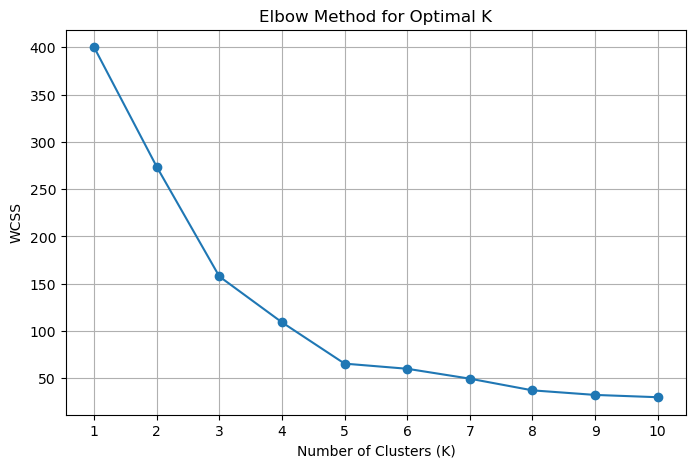

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(K_RANGE, wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(K_RANGE)
plt.grid(True)
plt.show()

## Train Final KMeans Model with Optimal K

In [39]:
OPTIMAL_K = 5
kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)


C:\Users\DHARANIDHARAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## Add Cluster Labels to Dataset

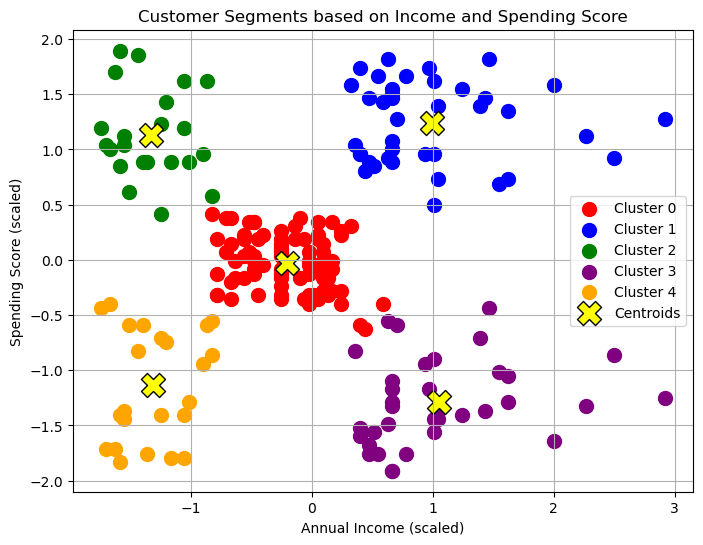

In [41]:

df['Cluster'] = y_kmeans

# Visualize Clusters
plt.figure(figsize=(8, 6))
colors = ['red', 'blue', 'green', 'purple', 'orange']

for i in range(OPTIMAL_K):
    plt.scatter(
        X_scaled[y_kmeans == i, 0],
        X_scaled[y_kmeans == i, 1],
        s=100,
        c=colors[i],
        label=f'Cluster {i}'
    )

# Plot Centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    c='yellow',
    edgecolors='black',
    marker='X',
    label='Centroids'
)

plt.title('Customer Segments based on Income and Spending Score')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.legend()
plt.grid(True)
plt.show()


## Analyze Cluster Characteristics

In [45]:
cluster_summary = df.groupby('Cluster')[features].mean()
print("\nCluster Averages:")
print(cluster_summary)


Cluster Averages:
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


# ============================
#  SUMMARY
# ============================
"""
K-Means clustering successfully segmented customers into 5 distinct groups based on
Annual Income and Spending Score.

Key Observations:
- Cluster 1 (High Income, High Spending) represents premium customers.
- Cluster 3 (High Income, Low Spending) are conservative spenders.
- Cluster 2 (Low Income, High Spending) likely represents young or impulsive buyers.
- Cluster 4 (Low Income, Low Spending) represents budget-conscious customers.
- Cluster 0 contains average income and moderate spending customers.

This segmentation can help businesses:
- Target high-value customers with exclusive offers.
- Design personalized marketing strategies for each segment.
- Improve overall customer retention and sales performance.
"""